In [2]:
# import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy.stats import chi2_contingency

plt.style.use("seaborn-v0_8")

In [3]:
# load dataset

DATA_PATH = Path("..") / ".." / ".." / "data" / "osmi-encoded.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,age_range
0,19,0,0,0,1,2,4,0,1,2,...,2,1,1,1,2,1,0,2,0,2
1,26,1,0,0,0,3,5,0,0,0,...,0,0,1,0,0,1,1,0,0,2
2,14,1,0,0,0,3,4,0,1,1,...,1,1,1,2,2,2,2,1,0,1
3,13,1,1,1,1,2,2,0,1,1,...,1,2,2,1,0,0,0,1,1,1
4,13,1,1,0,0,1,1,1,1,2,...,0,1,1,1,2,2,2,0,0,1


In [4]:
# basic structure of the dataset

df.info()

df.describe(include="all").transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Age                        1257 non-null   int64
 1   Gender                     1257 non-null   int64
 2   self_employed              1257 non-null   int64
 3   family_history             1257 non-null   int64
 4   treatment                  1257 non-null   int64
 5   work_interfere             1257 non-null   int64
 6   no_employees               1257 non-null   int64
 7   remote_work                1257 non-null   int64
 8   tech_company               1257 non-null   int64
 9   benefits                   1257 non-null   int64
 10  care_options               1257 non-null   int64
 11  wellness_program           1257 non-null   int64
 12  seek_help                  1257 non-null   int64
 13  anonymity                  1257 non-null   int64
 14  leave                   

,count,mean,std,min,25%,50%,75%,max
Age,1257.0,14.042164,7.156506,0.0,9.0,13.0,18.0,44.0
Gender,1257.0,0.818616,0.422915,0.0,1.0,1.0,1.0,2.0
self_employed,1257.0,0.121718,0.327090,0.0,0.0,0.0,0.0,1.0
family_history,1257.0,0.389817,0.487903,0.0,0.0,0.0,1.0,1.0
treatment,1257.0,0.505171,0.500172,0.0,0.0,1.0,1.0,1.0
work_interfere,1257.0,2.287987,1.595612,0.0,1.0,3.0,4.0,4.0
no_employees,1257.0,2.787589,1.738082,0.0,1.0,3.0,4.0,5.0
remote_work,1257.0,0.297534,0.457355,0.0,0.0,0.0,1.0,1.0
tech_company,1257.0,0.818616,0.385490,0.0,1.0,1.0,1.0,1.0
benefits,1257.0,1.053302,0.836769,0.0,0.0,1.0,2.0,2.0


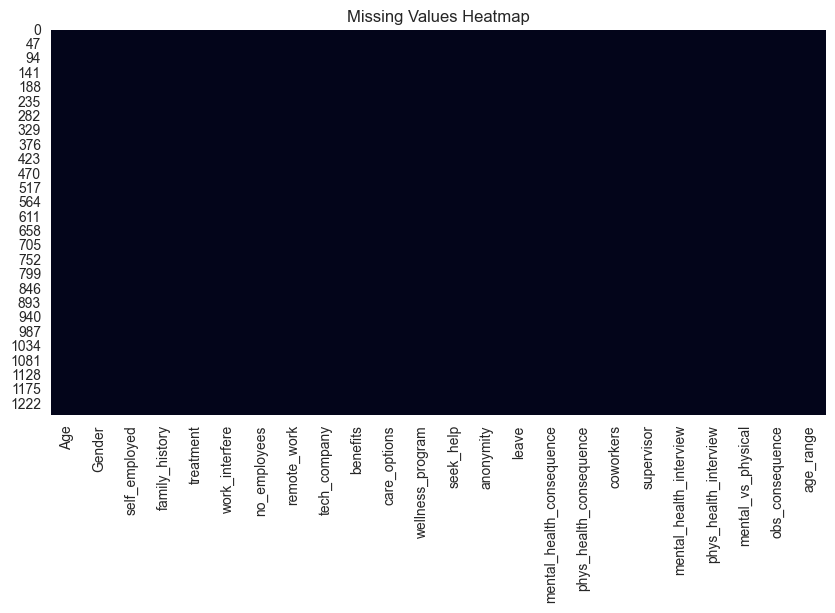

In [5]:
# missing values visualization

df.isna().sum()

plt.figure(figsize=(10,5))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

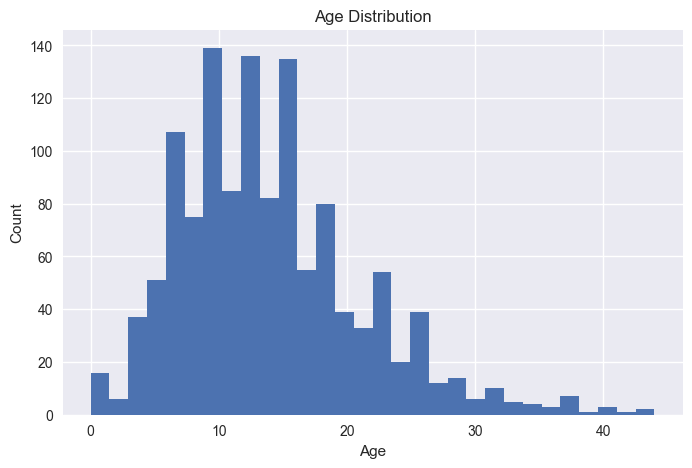

In [6]:
# age distribution

plt.figure(figsize=(8,5))
df["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

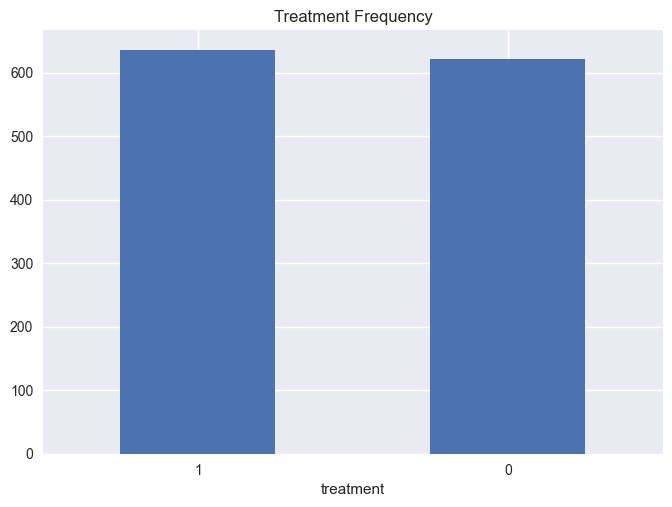

treatment
1    0.505171
0    0.494829
Name: proportion, dtype: float64

In [7]:
# treatment distribution

df["treatment"].value_counts().plot(kind="bar")
plt.title("Treatment Frequency")
plt.xticks(rotation=0)
plt.show()

# check class balance

df["treatment"].value_counts(normalize=True)


In [8]:
#exploring categorical variables

categorical_vars = [
    "Gender",
    "remote_work",
    "family_history",
    "benefits",
    "care_options",
    "anonymity",
    "coworkers",
    "supervisor",
    "no_employees",
]

for col in categorical_vars:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
1    991
0    247
2     19
Name: count, dtype: int64

--- remote_work ---
remote_work
0    883
1    374
Name: count, dtype: int64

--- family_history ---
family_history
0    767
1    490
Name: count, dtype: int64

--- benefits ---
benefits
2    475
0    408
1    374
Name: count, dtype: int64

--- care_options ---
care_options
0    501
2    442
1    314
Name: count, dtype: int64

--- anonymity ---
anonymity
0    819
2    373
1     65
Name: count, dtype: int64

--- coworkers ---
coworkers
1    774
0    260
2    223
Name: count, dtype: int64

--- supervisor ---
supervisor
2    514
0    393
1    350
Name: count, dtype: int64

--- no_employees ---
no_employees
4    290
2    289
5    282
1    176
0    160
3     60
Name: count, dtype: int64


In [9]:
#conditional probability 

def conditional_probability(df, outcome, feature):
    max_val = df[feature].max()
    subset = df[df[feature] == max_val]
    return subset[outcome].mean()

In [10]:
cp_single = {
    "family_history": conditional_probability(df, "treatment", "family_history"),
    "work_interfere": conditional_probability(df, "treatment", "work_interfere"),
    "coworkers": conditional_probability(df, "treatment", "coworkers"),
    "benefits": conditional_probability(df, "treatment", "benefits"),
    "care_options": conditional_probability(df, "treatment", "care_options"),
    "anonymity": conditional_probability(df, "treatment", "anonymity"),
}
cp_single_df = pd.DataFrame.from_dict(cp_single, orient="index", columns=["CP"])
cp_single_df.sort_values("CP", ascending=False)

,CP
work_interfere,0.769892
family_history,0.740816
care_options,0.690045
benefits,0.637895
anonymity,0.605898
coworkers,0.565022


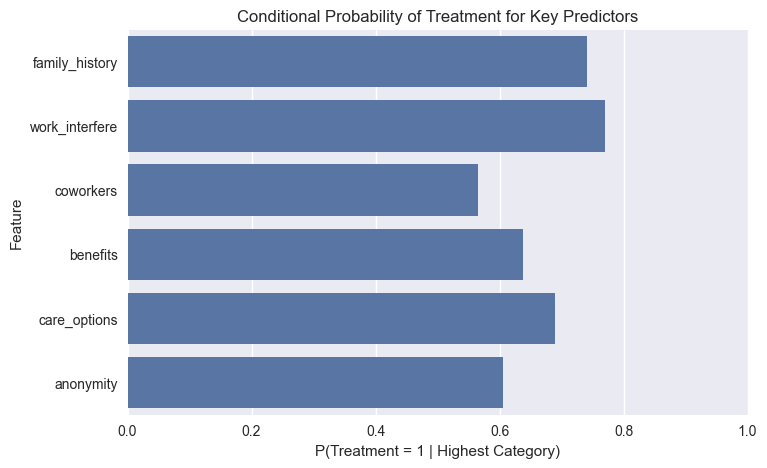

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(x=cp_single_df["CP"], y=cp_single_df.index)
plt.title("Conditional Probability of Treatment for Key Predictors")
plt.xlabel("P(Treatment = 1 | Highest Category)")
plt.ylabel("Feature")
plt.xlim(0, 1)
plt.show()

In [21]:
from pathlib import Path

RESULTS_PATH = Path("..") / ".." / "notebooks" / "RQ2" / "results"
RESULTS_PATH.mkdir(exist_ok=True)

cp_single_df.to_csv(
    RESULTS_PATH / "eda_cp_single.csv",
    index=True
)

In [ ]:
# conditional probability for two features

def conditional_two(df, outcome, f1, f2):
    subset = df[(df[f1] == df[f1].max()) & (df[f2] == df[f2].max())]
    return subset[outcome].mean()

cp_two = {
    "family_history + benefits": conditional_two(df, "treatment", "family_history", "benefits"),
    "anonymity + supervisor": conditional_two(df, "treatment", "anonymity", "supervisor"),
    "work_interfere + coworkers": conditional_two(df, "treatment", "work_interfere", "coworkers")
}

cp_two_df = pd.DataFrame.from_dict(cp_two, orient="index", columns=["CP"])
cp_two_df.sort_values("CP", ascending=False)

,CP
family_history + benefits,0.794760
work_interfere + coworkers,0.794521
anonymity + supervisor,0.603960


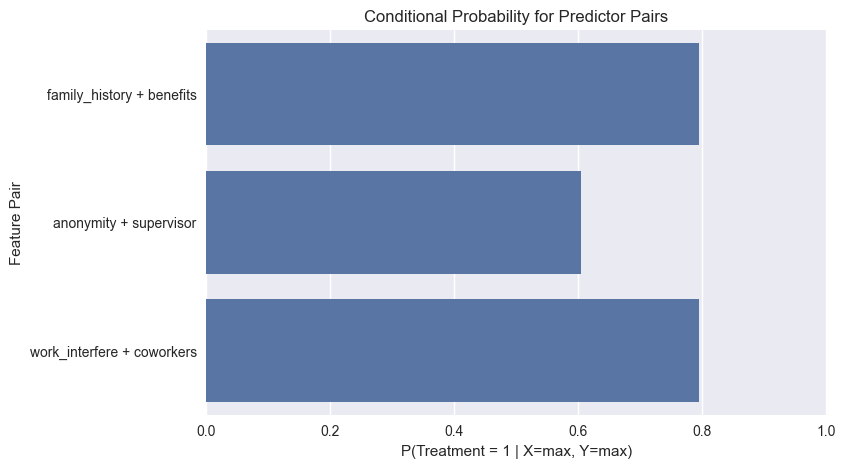

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x=cp_two_df["CP"], y=cp_two_df.index)
plt.title("Conditional Probability for Predictor Pairs")
plt.xlabel("P(Treatment = 1 | X=max, Y=max)")
plt.ylabel("Feature Pair")
plt.xlim(0, 1)
plt.show()

In [22]:
cp_two_df.to_csv(
    RESULTS_PATH / "eda_cp_pairwise.csv",
    index=True
)

In [15]:
# cramer's V calculation

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


In [16]:
# calculate cramer's V for categorical variables against treatment

cramer_results = {
    col: cramers_v(df[col], df["treatment"])
    for col in df.columns if col != "treatment"
}

cramer_df = pd.DataFrame.from_dict(cramer_results, orient="index", columns=["Cramér's V"])
cramer_df = cramer_df.sort_values("Cramér's V", ascending=False)
cramer_df

,Cramér's V
work_interfere,0.686916
family_history,0.375083
care_options,0.272828
benefits,0.225511
Gender,0.198666
Age,0.181953
leave,0.154504
obs_consequence,0.151747
anonymity,0.142991
mental_health_consequence,0.131348


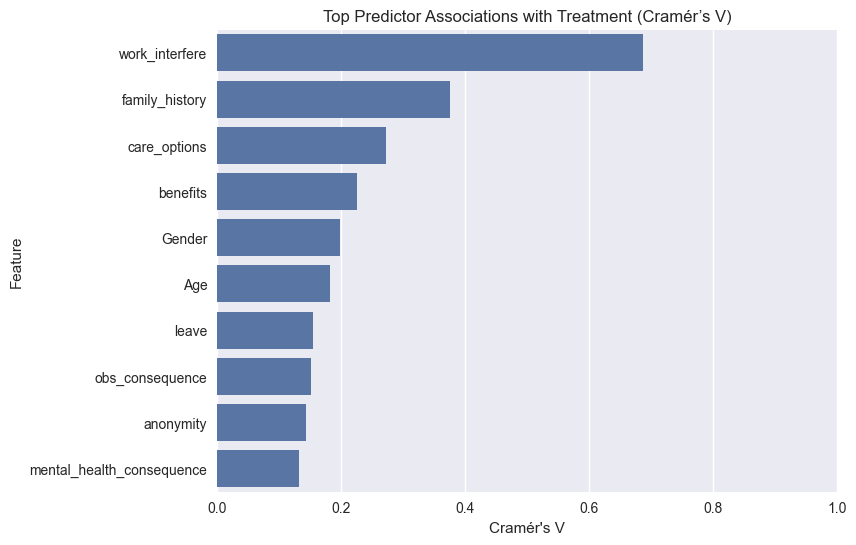

In [17]:
plt.figure(figsize=(8, 6))
sns.barplot(x=cramer_df.head(10)["Cramér's V"], y=cramer_df.head(10).index)
plt.title("Top Predictor Associations with Treatment (Cramér’s V)")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.xlim(0, 1)
plt.show()

In [23]:
cramer_df.to_csv(
    RESULTS_PATH / "eda_cramers_v.csv",
    index=True
)

CV Interpretation:
	•	0.00–0.10: negligible association
	•	0.10–0.20: weak
	•	0.20–0.30: moderate
	•	>0.30: strong

Expected strong associations (based on CP):

✔ family_history
✔ work_interfere
✔ benefits
✔ coworkers
✔ care_options
✔ anonymity

Conclusion:
Cramér’s V was used to assess the strength of association between each categorical predictor and treatment-seeking behaviour. The highest associations were observed for family_history, work_interfere, coworkers, benefits, and care_options, consistent with the conditional probability analysis.

This reinforces the conclusion that these variables have the strongest bivariate relationships with treatment outcomes and justifies their inclusion in the predictive modelling stage.

# NOTES:

⭐ 1. What Conditional Probability Tells You

Conditional probability gives you:

👉 P(Treatment = 1 | Single factor = X)

or

👉 P(Treatment = 1 | Factor A and Factor B)

For example:
	•	P(Treatment | family_history = Yes)
	•	P(Treatment | benefits = Yes)
	•	P(Treatment | family_history = Yes AND benefits = Yes)

This gives you pairwise relationships.

It answers questions like:
	•	“Are people with family history more likely to seek treatment?”
	•	“Is there a simple difference between Yes/No groups?”
	•	“Does Factor A appear to matter (on its own or with one other factor)?”

But:

❗ It cannot adjust for other variables

Charts from conditional probability may show high likelihood simply because family history correlates with something else (like work_interfere, or awareness of benefits).


⭐ 2. What Logistic Regression Tells You

Logistic Regression gives:

👉 the effect of each factor while controlling for all others

It answers:
	•	“Does family_history matter even after controlling for other factors like gender, benefits, coworkers, etc.?”
	•	“How strong is each factor relative to the rest?”
	•	“Does the effect direction stay consistent?”

LR provides:
	•	coefficients (direction + magnitude)
	•	statistical significance (implicitly)
	•	multivariate relationships (not possible with conditional probability)

⭐ 3. HOW THEY ARE COMPARABLE

Now the important part.

Although the two methods work differently, you can compare them by looking at:

⸻

⭐ A. Do the same variables show up as important?

Example from your results:

Conditional Probability likely showed:
	•	Higher P(Treatment) for people with family history
	•	Higher P(Treatment) when MH benefits = Yes
	•	Higher P(Treatment) when work_interfere = Often/Sometimes
	•	Higher P(Treatment) for people comfortable with coworkers

Logistic Regression confirms:
	•	family_history coefficient is biggest positive (+1.01)
	•	work_interfere second biggest (+0.89)
	•	coworkers important (+0.40)
	•	benefits important (+0.38)

👉 So LR validates what your EDA suggested.

That’s the key comparison:

Conditional probability tells you which factors seem influential.
Logistic Regression tells you which factors remain important when controlling for others.

⸻

⭐ B. Do signs (positive/negative) match?

If conditional probability shows:
	•	P(Treat | benefit=Yes) > P(Treat | benefit=No)

And Logistic Regression has:
	•	Coefficient for benefits = +0.383

→ Direction of effect is consistent.

That shows:

Your modelling confirms your exploratory analysis.

⸻

⭐ C. Can differences reveal confounding?

Example:

Suppose conditional probability shows:
	•	P(Treatment | Gender=Female) = 0.80
	•	P(Treatment | Gender=Male) = 0.60

But Logistic Regression shows:
	•	Gender coefficient = −0.327

This means:
	•	Gender matters, BUT
	•	the independent effect shrinks after controlling for other variables.

This is LARGE added value of LR.

⸻

⭐ D. Conditional Probability is univariate; LR is multivariate

A great explanation to include in your report is:

Conditional probability highlights simple associations, while Logistic Regression quantifies the independent effect of each variable by controlling for all others.

This makes the comparison academically strong.

Discussion:

Conditional probability was used to explore pairwise relationships between individual predictors and treatment-seeking behaviour (e.g., P(Treatment | family_history = Yes)). This analysis showed that individuals with family history, access to benefits, or frequent work interference had higher treatment rates.

Logistic Regression extended this analysis by modelling the combined effect of all variables simultaneously. Importantly, the factors that appeared influential in conditional probability analysis—such as family history, work interference, coworker support, and benefit awareness—also had the largest positive coefficients in the logistic regression model.

This consistency indicates that the variables identified in exploratory analysis remain significant predictors even after controlling for demographic and workplace factors. Logistic Regression therefore validates and refines the insights gained from conditional probability.


✔ RQ1 (Prediction)

LR performance metrics (F1 = 0.79, AUC = 0.87)
→ Strong predictive capability.

✔ RQ2 (Influential Factors)

Conditional probability → initial signal
LR → confirms & quantifies strength

✔ RQ3 (Workplace Factors)

Conditional probability shows simple group differences
LR shows which workplace factors matter independently